In [19]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat

In [20]:
# Each subjets electrode locations, registered to MNI space, in mm
aa_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy")
ap_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy")
ca_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy")
de_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy")
fp_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy")
ha_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy")
ja_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy")
jm_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy")
jt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy")
mv_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy")
rn_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy")
rr_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/rr_xslocs_registered_mm.npy")
wc_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/wc_xslocs_registered_mm.npy")
zt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/zt_xslocs_registered_mm.npy")

In [21]:
# All subjects' electrode locations in mni

all_electrodes = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/all_electrodes_mni_locs.npy")


In [22]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
from scipy import signal, stats

project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
registered_dir = project_root / 'registered_outputs'
data_root = Path('/Users/rustin/Documents/Big Data 567/faces_basic/data')
out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
out_dir.mkdir(parents=True, exist_ok=True)

srate = 1000  # Hz
sos_notch = signal.butter(4, [59.5, 60.5], btype='bandstop', fs=srate, output='sos')
kurtosis_thresh = 10  # drop channels with kurtosis >= 10 (same as SuperEEG paper)

print(f'Registered locs dir: {registered_dir}')
print(f'ECoG data dir:      {data_root}')
print(f'Per-subject output: {out_dir}')


Registered locs dir: /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs
ECoG data dir:      /Users/rustin/Documents/Big Data 567/faces_basic/data
Per-subject output: /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed


In [23]:
from scipy.stats import kurtosis

for npy_file in sorted(registered_dir.glob('*_xslocs_registered_mm.npy')):
    pid = npy_file.stem.split('_')[0]
    locs = np.load(npy_file).astype(np.float32, copy=False)

    mat_path = data_root / pid / f'{pid}_faceshouses.mat'
    if not mat_path.exists():
        print(f'[{pid}] missing ECoG file: {mat_path}')
        continue

    mat = loadmat(mat_path, squeeze_me=True)
    ecog = mat['data'].astype(np.float32, copy=False)
    stim = mat.get('stim')
    if stim is None:
        print(f'[{pid}] missing stim array')
        continue
    stim = np.asarray(stim, dtype=np.int32).ravel()
    if ecog.shape[0] != stim.shape[0]:
        print(f'[{pid}] length mismatch: ecog {ecog.shape[0]} vs stim {stim.shape[0]}')
        continue

    # keep only stimulus != 0 samples
    mask = stim != 0
    ecog_nz = ecog[mask]
    stim_nz = stim[mask]
    if ecog_nz.shape[0] == 0:
        print(f'[{pid}] no non-zero stimulus samples; skipped')
        continue

    # notch filter first
    filtered_ecog = signal.sosfiltfilt(sos_notch, ecog_nz, axis=0).astype(np.float32, copy=False)

    # kurtosis threshold on filtered data (time-domain), axis=0 per channel
    k = kurtosis(filtered_ecog, axis=0, fisher=False, bias=False)
    good_idx = np.where(k <= 10)[0]
    if good_idx.size < 2:
        print(f'[{pid}] only {good_idx.size} channels after kurtosis filter; skipped')
        continue

    cleaned_ecog = filtered_ecog[:, good_idx]
    cleaned_locs = locs[good_idx]

    loc_out = out_dir / f'{pid}_locs_mni_mm.npy'
    ecog_out = out_dir / f'{pid}_ecog_filtered.npy'
    stim_out = out_dir / f'{pid}_stim_nonzero.npy'
    np.save(loc_out, cleaned_locs)
    np.save(ecog_out, cleaned_ecog)
    np.save(stim_out, stim_nz)

    dropped = locs.shape[0] - good_idx.size
    print(f'[{pid}] kept {good_idx.size}/{locs.shape[0]} channels (dropped {dropped} kurtosis>10)')
    print(f'[{pid}] locs {cleaned_locs.shape} -> {loc_out.name}')
    print(f'[{pid}] filtered ecog {cleaned_ecog.shape} -> {ecog_out.name}')
    print(f'[{pid}] stim nonzero {stim_nz.shape} -> {stim_out.name}')


[aa] kept 39/46 channels (dropped 7 kurtosis>10)
[aa] locs (39, 3) -> aa_locs_mni_mm.npy
[aa] filtered ecog (244200, 39) -> aa_ecog_filtered.npy
[aa] stim nonzero (244200,) -> aa_stim_nonzero.npy
[ap] kept 40/41 channels (dropped 1 kurtosis>10)
[ap] locs (40, 3) -> ap_locs_mni_mm.npy
[ap] filtered ecog (241200, 40) -> ap_ecog_filtered.npy
[ap] stim nonzero (241200,) -> ap_stim_nonzero.npy
[ca] kept 49/50 channels (dropped 1 kurtosis>10)
[ca] locs (49, 3) -> ca_locs_mni_mm.npy
[ca] filtered ecog (244200, 49) -> ca_ecog_filtered.npy
[ca] stim nonzero (244200,) -> ca_stim_nonzero.npy
[de] kept 31/31 channels (dropped 0 kurtosis>10)
[de] locs (31, 3) -> de_locs_mni_mm.npy
[de] filtered ecog (244200, 31) -> de_ecog_filtered.npy
[de] stim nonzero (244200,) -> de_stim_nonzero.npy
[fp] kept 50/52 channels (dropped 2 kurtosis>10)
[fp] locs (50, 3) -> fp_locs_mni_mm.npy
[fp] filtered ecog (244200, 50) -> fp_ecog_filtered.npy
[fp] stim nonzero (244200,) -> fp_stim_nonzero.npy
[ha] kept 38/39 chan

# Quick look at first subject (all electrodes over time, stim≠0 only)


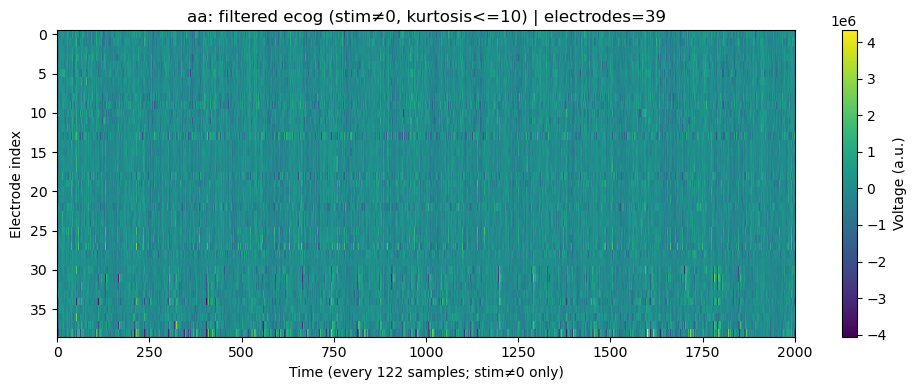

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
ecog_files = sorted(out_dir.glob('*_ecog_filtered.npy'))
if not ecog_files:
    raise FileNotFoundError('No filtered ecog files found in output dir')
first_ecog_path = ecog_files[0]
pid = first_ecog_path.stem.split('_')[0]
ecog = np.load(first_ecog_path)
locs = np.load(out_dir / f'{pid}_locs_mni_mm.npy')
stim = np.load(out_dir / f'{pid}_stim_nonzero.npy')

step = max(1, ecog.shape[0] // 2000)
ecog_ds = ecog[::step]

plt.figure(figsize=(10, 4))
im = plt.imshow(ecog_ds.T, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(im, label='Voltage (a.u.)')
plt.xlabel(f'Time (every {step} samples; stim≠0 only)')
plt.ylabel('Electrode index')
plt.title(f'{pid}: filtered ecog (stim≠0, kurtosis<=10) | electrodes={locs.shape[0]}')
plt.tight_layout()
plt.show()


# Optional: combine preprocessed subjects later


In [26]:
# Run after per-subject files exist
from pathlib import Path
import numpy as np

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
records = []
for loc_path in sorted(out_dir.glob('*_locs_mni_mm.npy')):
    pid = loc_path.stem.split('_')[0]
    ecog_path = out_dir / f'{pid}_ecog_filtered.npy'
    stim_path = out_dir / f'{pid}_stim_nonzero.npy'
    if not ecog_path.exists():
        print(f'[{pid}] missing filtered ecog: {ecog_path}')
        continue
    ecog = np.load(ecog_path)
    locs = np.load(loc_path)
    stim = np.load(stim_path) if stim_path.exists() else None
    records.append({'patient_id': pid, 'locs_mni_mm': locs, 'ecog': ecog, 'stim_nonzero': stim})

combined_path = out_dir / 'all_locs_mni_and_ecog_preprocessed.npy'
np.save(combined_path, np.array(records, dtype=object))
print(f'Combined {len(records)} patients to {combined_path}')


Combined 13 patients to /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed/all_locs_mni_and_ecog_preprocessed.npy


In [32]:
import numpy as np

path = "/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed/all_locs_mni_and_ecog_preprocessed.npy"
all_locs = np.load(path, allow_pickle=True)

print(all_locs.shape)          # (13,)
print(all_locs[0].keys())      # patient_id, locs_mni_mm, ecog, stim_nonzero


(13,)
dict_keys(['patient_id', 'locs_mni_mm', 'ecog', 'stim_nonzero'])
